In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

TasksTask 1: Load and Inspect Data
Import required libraries
Load dataset using Pandas
Display first 5 rows
Check:
Data types
Missing values
Summary statistics
👉 Questions:How many rows and columns are present?
Are there missing values?

In [6]:
#laod the data
df=pd.read_csv('headbrain11.csv')


In [7]:
#display the first 5 rows
df.head()

,Head Size(cm^3),Brain Weight(grams)
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


In [11]:
#check data stypes
df.dtypes

Head Size(cm^3)        int64
Brain Weight(grams)    int64
dtype: object

In [14]:
#check missing avlues
df.isnull().sum()

Head Size(cm^3)        0
Brain Weight(grams)    0
dtype: int64

In [15]:
#6. Summary Statistics
df.describe

<bound method NDFrame.describe of      Head Size(cm^3)  Brain Weight(grams)
0               4512                 1530
1               3738                 1297
2               4261                 1335
3               3777                 1282
4               4177                 1590
..               ...                  ...
232             3214                 1110
233             3394                 1215
234             3233                 1104
235             3352                 1170
236             3391                 1120

[237 rows x 2 columns]>

In [ ]:
#questions
df.shape #output (237,2) so there are 237 rows and 2 columns
df.isnull().sum() # result 0.

Head Size(cm^3)        0
Brain Weight(grams)    0
dtype: int64

Task 2: Data Cleaning

In [ ]:
#Rename columns:['Head_size', 'Brain_weight'] 
df=df.rename(columns={
    'Head Size(cm^3)': 'Head_size',
    'Brain Weight(grams)': 'Brain_weight'
})
df.head()


,Head_size,Brain_weight
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


renaming coulmns is useful:
Avoids Errors in Code
    Column names with:
        Spaces (Head Size)
        Special characters (cm^3, ())
        Mixed formatting
can cause syntax errors or require special handling (like backticks or brackets).
Head_size is clean and easy to reference.

Improves Readability
Short, consistent names make models easier to understand.

Required by Some ML Libraries
Some machine learning tools and pipelines:
Prefer clean feature names
May break with special characters
Work better with standardized naming conventions

Enables Consistency in Pipelines
When building larger ML pipelines, consistent column naming:
Prevents bugs
Makes feature engineering easier
Improves collaboration with teams

Task 3: Exploratory Data Analysis (EDA)
Create:
✔ Scatterplot
✔ Regression plot
✔ Histogram of both variables
✔ Boxplot
👉 Questions:Describe the relationship between head size and brain weight.
Is the relationship positive or negative?

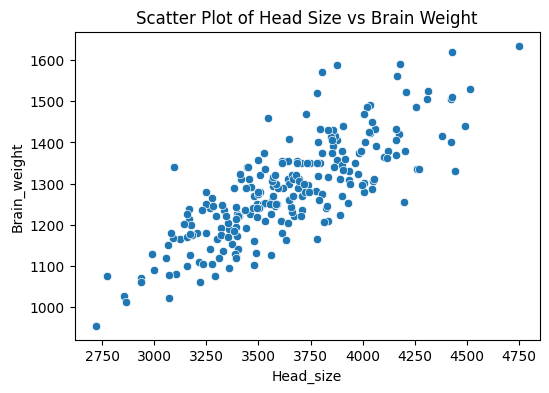

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Head_size',y='Brain_weight',data=df)
plt.title("Scatter Plot of Head Size vs Brain Weight")
plt.show()

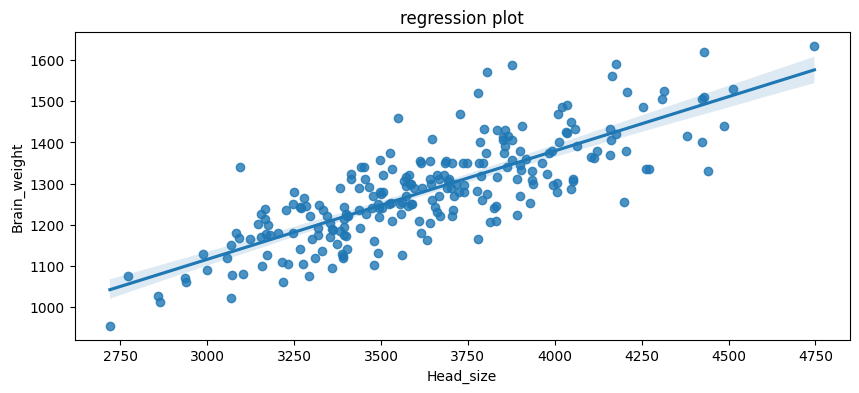

In [26]:
plt.figure(figsize=(10,4))
sns.regplot(x='Head_size',y='Brain_weight',data=df)
plt.title('regression plot')
plt.show()

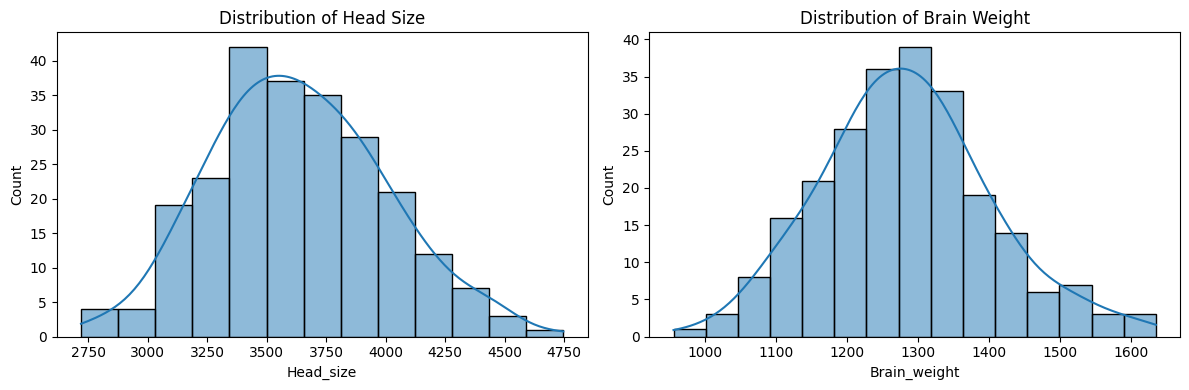

In [27]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Head_size'], kde=True)
plt.title("Distribution of Head Size")

plt.subplot(1,2,2)
sns.histplot(df['Brain_weight'], kde=True)
plt.title("Distribution of Brain Weight")

plt.tight_layout()
plt.show()

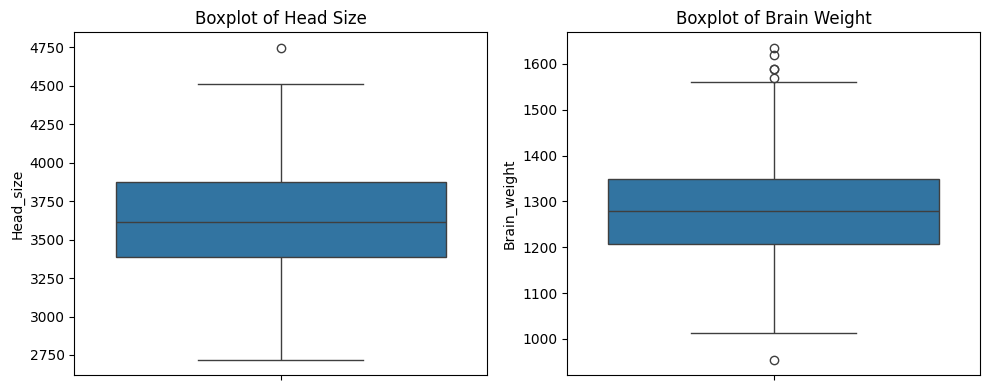

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df['Head_size'])
plt.title("Boxplot of Head Size")

plt.subplot(1,2,2)
sns.boxplot(y=df['Brain_weight'])
plt.title("Boxplot of Brain Weight")

plt.tight_layout()
plt.show()

Questions:Describe the relationship between head size and brain weight.
Is the relationship positive or negative?

From the scatter plot and regression plot, we can observe:
    Points forming an upward trend
    As Head_size increases, Brain_weight also increases
    The regression line slopes upward
    The relationship appears approximately linear
    This suggests a strong linear relationship.

The relationship is: Positive Relationship
Because:
Larger head sizes correspond to larger brain weights
The regression line has a positive slope


Task 4: Fit Linear Regression (Statsmodels OLS)
Fit model:

👉 Questions:Write the regression equation.
Interpret the slope.
What is the R² value?
Is the predictor statistically significant?

In [30]:
X = df['Head_size']
y = df['Brain_weight']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Brain_weight   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     416.5
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           5.96e-54
Time:                        17:22:25   Log-Likelihood:                -1350.3
No. Observations:                 237   AIC:                             2705.
Df Residuals:                     235   BIC:                             2711.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        325.5734     47.141      6.906      0.0

1. Regression Equation
From our results:
    Intercept (β₀) = 325.5734
    Slope (β₁) = 0.2634
Regression Equation:
Brain_weight=325.5734+0.2634×Head_size
Brain_weight=325.5734+0.2634×Head_size

2. Interpret the Slope
Slope = 0.2634
This means:For every 1 unit increase in head size, brain weight increases by 0.2634 units on average.
-> The relationship is positive
-> Larger head sizes are associated with larger brain weights

3. What is the R² Value?

From our output:𝑅2=0.639R2=0.639
Interpretation:63.9% of the variation in brain weight is explained by head size.
This is a strong relationship for a simple linear regression with only one predictor.
Adjusted R² = 0.638 (very close → good model stability)

4. Is the Predictor Statistically Significant?
the p-value for Head_size:𝑝=0.000p=0.000
Since:𝑝<0.05p<0.05
Yes, the predictor is statistically significant.
This means head size is a meaningful predictor of brain weight.

Task 5: Model Interpretation
Explain:
✔ R-squared
✔ Coefficients
✔ P-value
✔ F-statistic
👉 Question:
What does R² = X imply?

R-squared (R²)
In my model, R² = 0.639.
This means that 63.9% of the variation in brain weight is explained by head size.
The remaining 36.1% of the variation is due to other factors or random error.
This indicates that my model has strong explanatory power for a simple linear regression.

Coefficients
My regression equation is:Brain_weight=325.5734+0.2634(Head_size)
Intercept (325.5734)
The intercept represents the predicted brain weight when head size is 0.
Although this may not have practical meaning, it is necessary for forming the regression line.

Slope (0.2634)
The slope tells me that:
For every 1 unit increase in head size, brain weight increases by 0.2634 units on average.
Since the slope is positive, this shows that there is a positive relationship between head size and brain weight.

P-value
The p-value for head size is less than 0.001.
Since this is less than 0.05, I reject the null hypothesis that the slope is equal to zero.
This means head size is a statistically significant predictor of brain weight in my model.

F-statistic
The F-statistic of 416.5 tests whether my regression model as a whole is significant.
Because the associated probability is extremely small (5.96e-54), I conclude that my overall model is statistically significant.

What does R² = 0.639 imply?
R² = 0.639 implies that 63.9% of the variation in brain weight is explained by head size in my model.
This suggests that head size is a strong predictor of brain weight, although some variation remains unexplained.